<a href="https://colab.research.google.com/github/henryparfait/linear_regression_model/blob/main/summative/linear_regression/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Progression Prediction Using Linear Regression

**Mission:** Applying AI Tools in Healthcare  
**Problem:** Predicting diabetes disease progression one year after baseline using patient clinical metrics.  
**Dataset:** Scikit-learn Diabetes Dataset — 442 patients, 10 baseline features, 1 continuous target.  
**Source:** Originally from Bradley Efron, Trevor Hastie, Iain Johnstone and Robert Tibshirani (2004) *"Least Angle Regression"*, Annals of Statistics. Hosted in `sklearn.datasets`.

---

## 1. Setup & Data Loading

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
# ── Load the Diabetes Dataset ────────────────────────────────────────────────
diabetes = load_diabetes()

# Build a clean DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target  # continuous measure of disease progression

print(f"Dataset shape: {df.shape}")
print(f"Number of patients: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")
print(f"\nFeature descriptions:")
print("  age  – Age of patient")
print("  sex  – Gender indicator")
print("  bmi  – Body mass index")
print("  bp   – Average blood pressure")
print("  s1   – Total serum cholesterol (tc)")
print("  s2   – Low-density lipoproteins (ldl)")
print("  s3   – High-density lipoproteins (hdl)")
print("  s4   – Total cholesterol / HDL ratio (tch)")
print("  s5   – Log of serum triglycerides (ltg)")
print("  s6   – Blood sugar level (glu)")
print("  target – Disease progression measure (continuous)")

Dataset shape: (442, 11)
Number of patients: 442
Number of features: 10

Feature descriptions:
  age  – Age of patient
  sex  – Gender indicator
  bmi  – Body mass index
  bp   – Average blood pressure
  s1   – Total serum cholesterol (tc)
  s2   – Low-density lipoproteins (ldl)
  s3   – High-density lipoproteins (hdl)
  s4   – Total cholesterol / HDL ratio (tch)
  s5   – Log of serum triglycerides (ltg)
  s6   – Blood sugar level (glu)
  target – Disease progression measure (continuous)


In [3]:
# ── Basic Exploration ────────────────────────────────────────────────────────
print("First 5 rows:")
df.head()

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [5]:
print("\nStatistical Summary:")
df.describe().round(3)


Statistical Summary:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


In [6]:
# ── Check for missing values and data types ─────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nData types:\n{df.dtypes}")
print("\n✅ All features are already numeric (float64). No conversion needed.")
print("✅ No missing values detected.")

Missing values per column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Total missing values: 0

Data types:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

✅ All features are already numeric (float64). No conversion needed.
✅ No missing values detected.


---
## 2. Data Visualization & Interpretation

We create meaningful visualizations to understand the data distribution, relationships between features, and how they relate to diabetes progression.

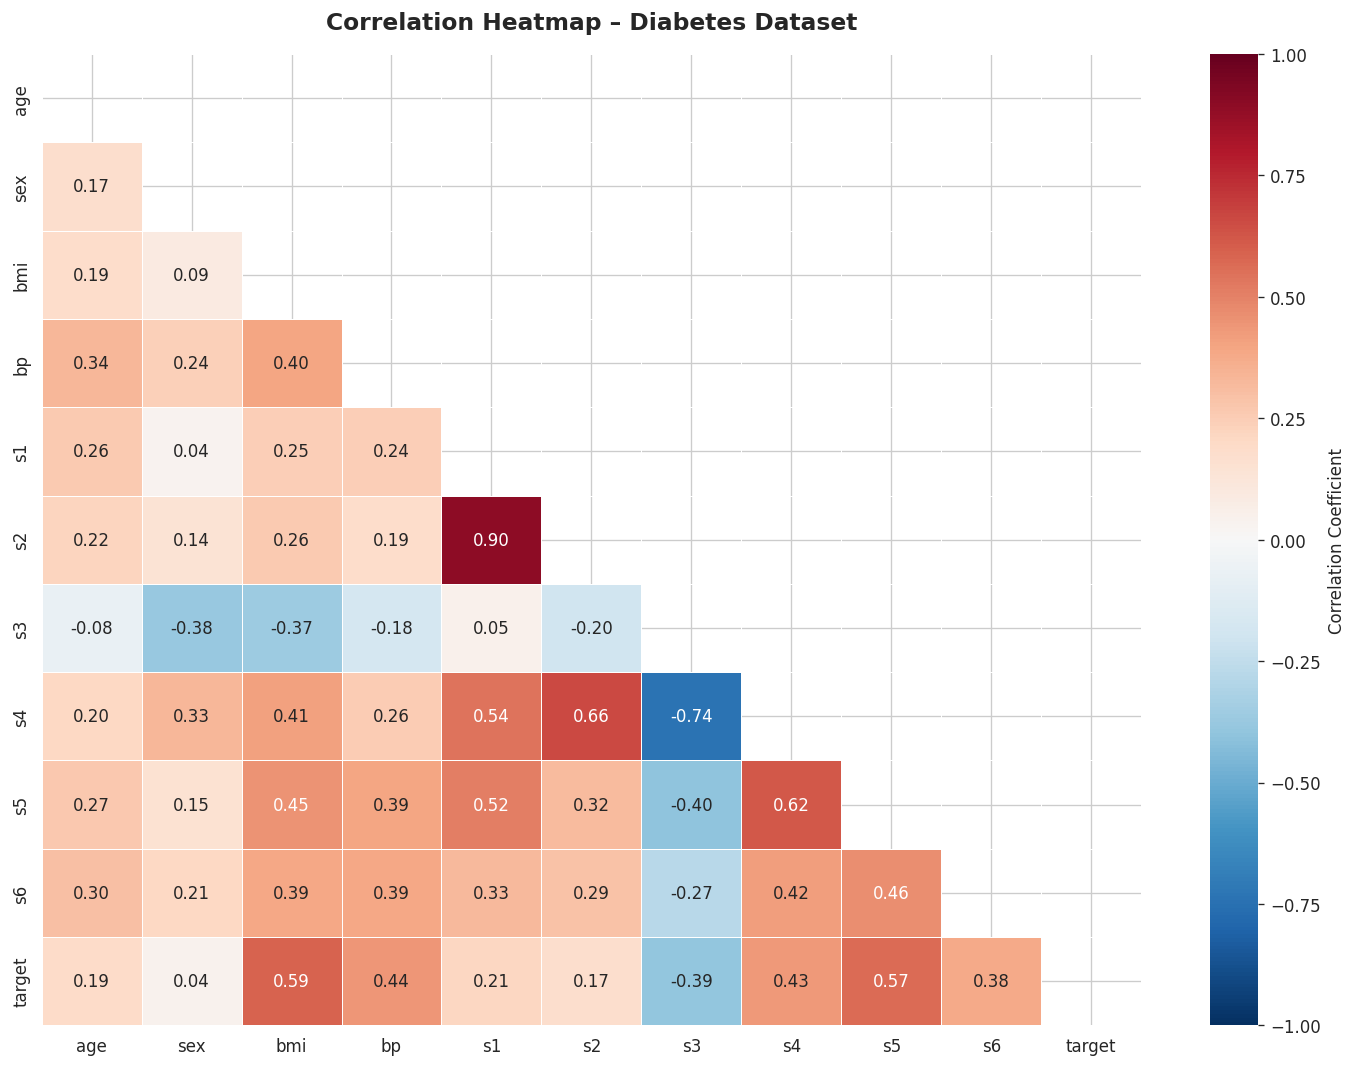


📊 Interpretation:
• bmi, s5 (log triglycerides), and bp (blood pressure) show the strongest positive
  correlations with the target (disease progression).
• s3 (HDL cholesterol) is negatively correlated with the target – higher HDL
  is associated with slower disease progression, which is medically expected.
• s1 and s2 are highly correlated with each other (multicollinearity), which
  may warrant dropping one during feature engineering.


In [7]:
# ── 2.1 Correlation Heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Heatmap – Diabetes Dataset', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("• bmi, s5 (log triglycerides), and bp (blood pressure) show the strongest positive")
print("  correlations with the target (disease progression).")
print("• s3 (HDL cholesterol) is negatively correlated with the target – higher HDL")
print("  is associated with slower disease progression, which is medically expected.")
print("• s1 and s2 are highly correlated with each other (multicollinearity), which")
print("  may warrant dropping one during feature engineering.")

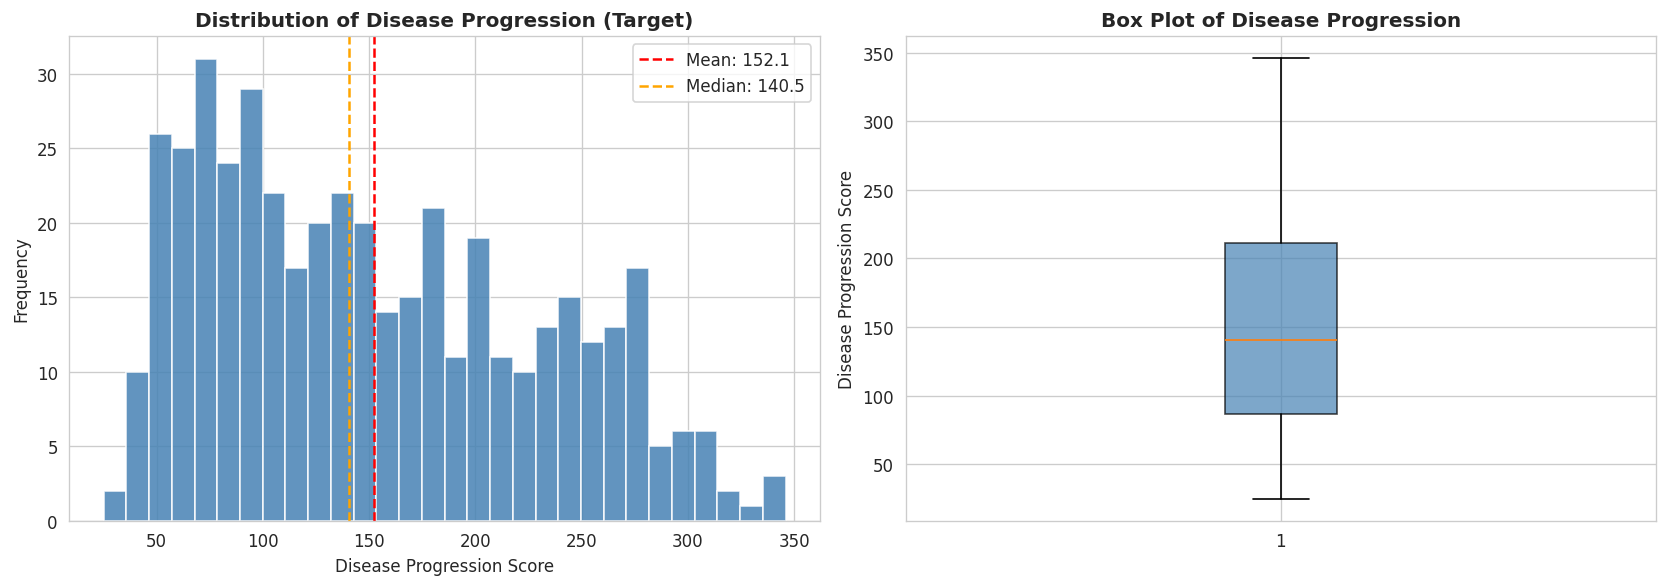


📊 Interpretation:
• The target variable is roughly right-skewed with a range of 25–346.
• Mean (~152) is slightly above the median (~140.5), confirming the mild skew.
• A few high-progression outliers exist but are not extreme enough to require removal.


In [8]:
# ── 2.2 Target Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['target'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['target'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['target'].mean():.1f}")
axes[0].axvline(df['target'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['target'].median():.1f}")
axes[0].set_title('Distribution of Disease Progression (Target)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Disease Progression Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df['target'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot of Disease Progression', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Disease Progression Score')

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("• The target variable is roughly right-skewed with a range of 25–346.")
print("• Mean (~152) is slightly above the median (~140.5), confirming the mild skew.")
print("• A few high-progression outliers exist but are not extreme enough to require removal.")

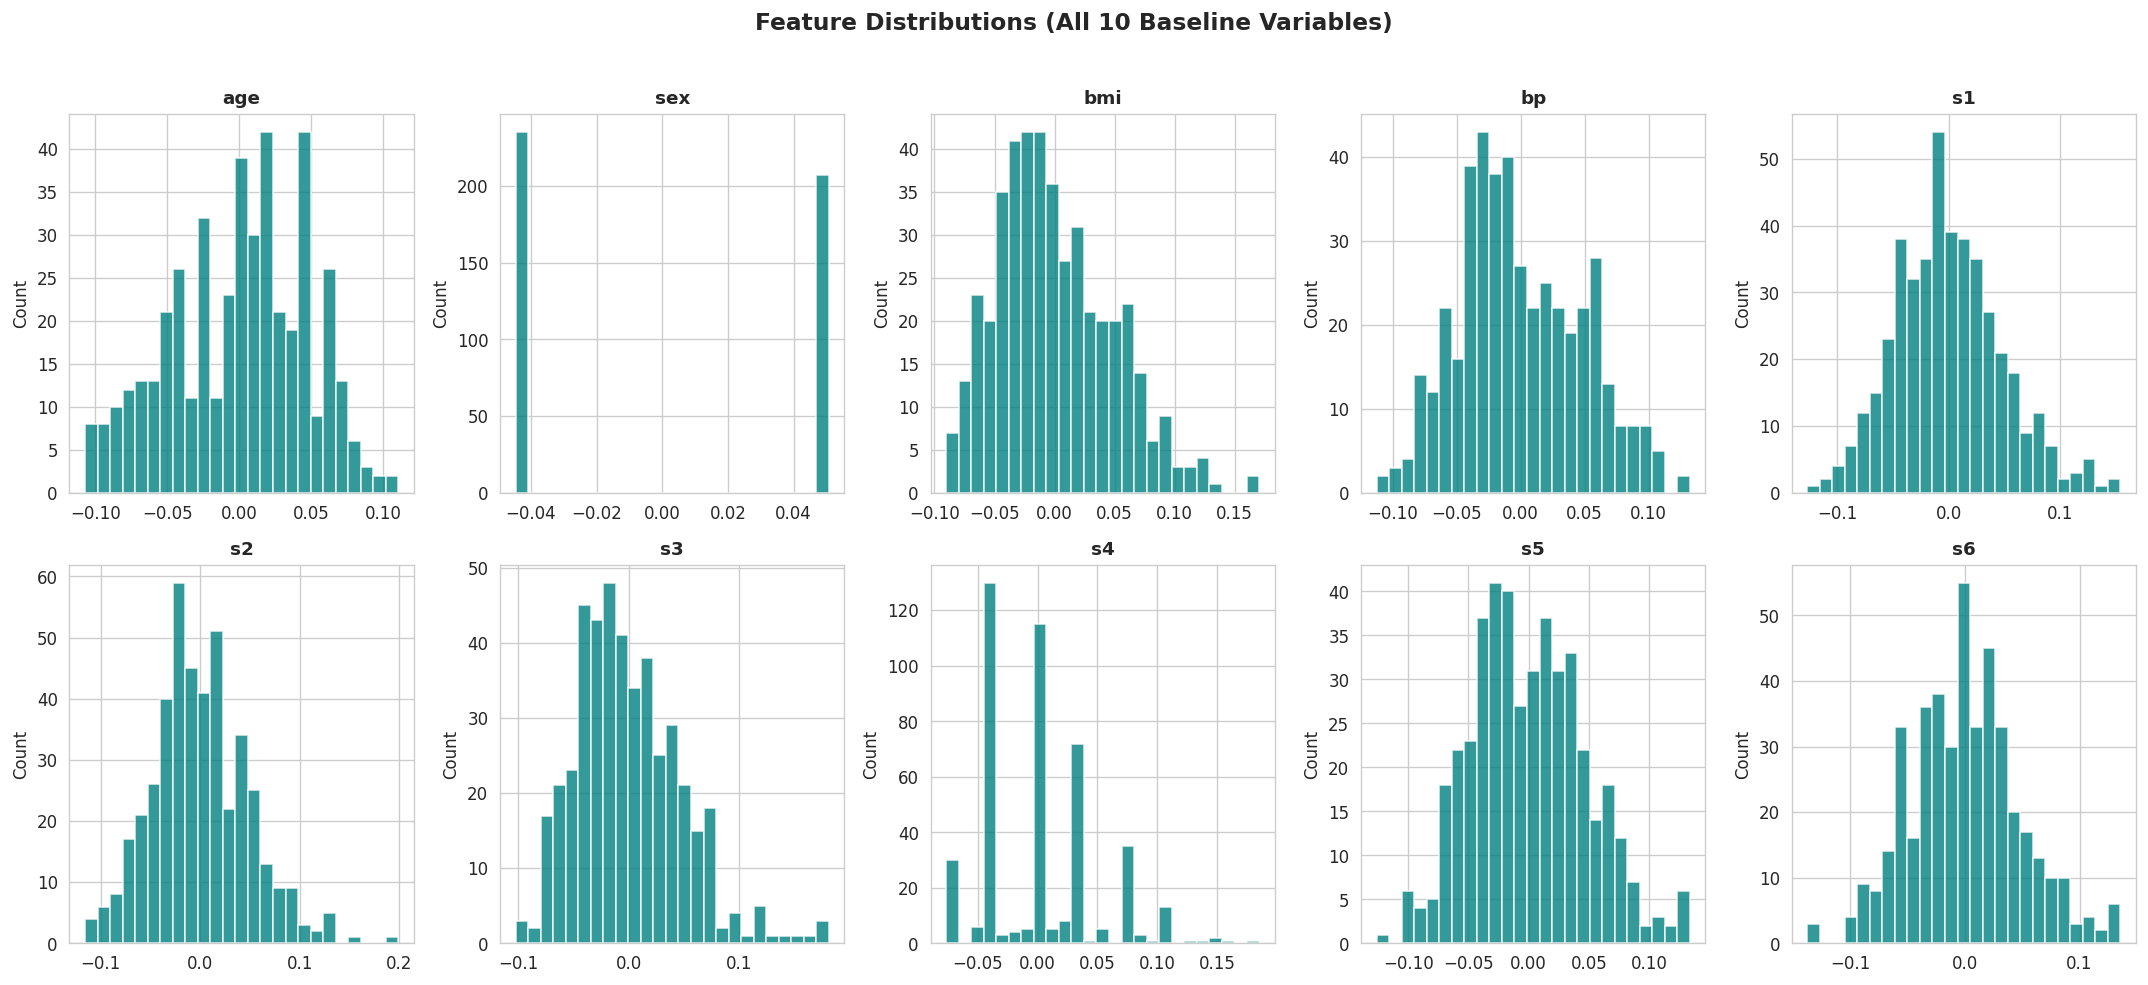


📊 Interpretation:
• The dataset was pre-processed: each feature is mean-centered and scaled by
  the standard deviation × n_samples, so distributions appear roughly symmetric.
• 'sex' is binary (two peaks), while all other features are continuous.
• bmi and s5 show the widest spread, suggesting they carry high variance/information.


In [9]:
# ── 2.3 Feature Distributions (Histograms) ──────────────────────────────────
features = diabetes.feature_names
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

fig.suptitle('Feature Distributions (All 10 Baseline Variables)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("• The dataset was pre-processed: each feature is mean-centered and scaled by")
print("  the standard deviation × n_samples, so distributions appear roughly symmetric.")
print("• 'sex' is binary (two peaks), while all other features are continuous.")
print("• bmi and s5 show the widest spread, suggesting they carry high variance/information.")

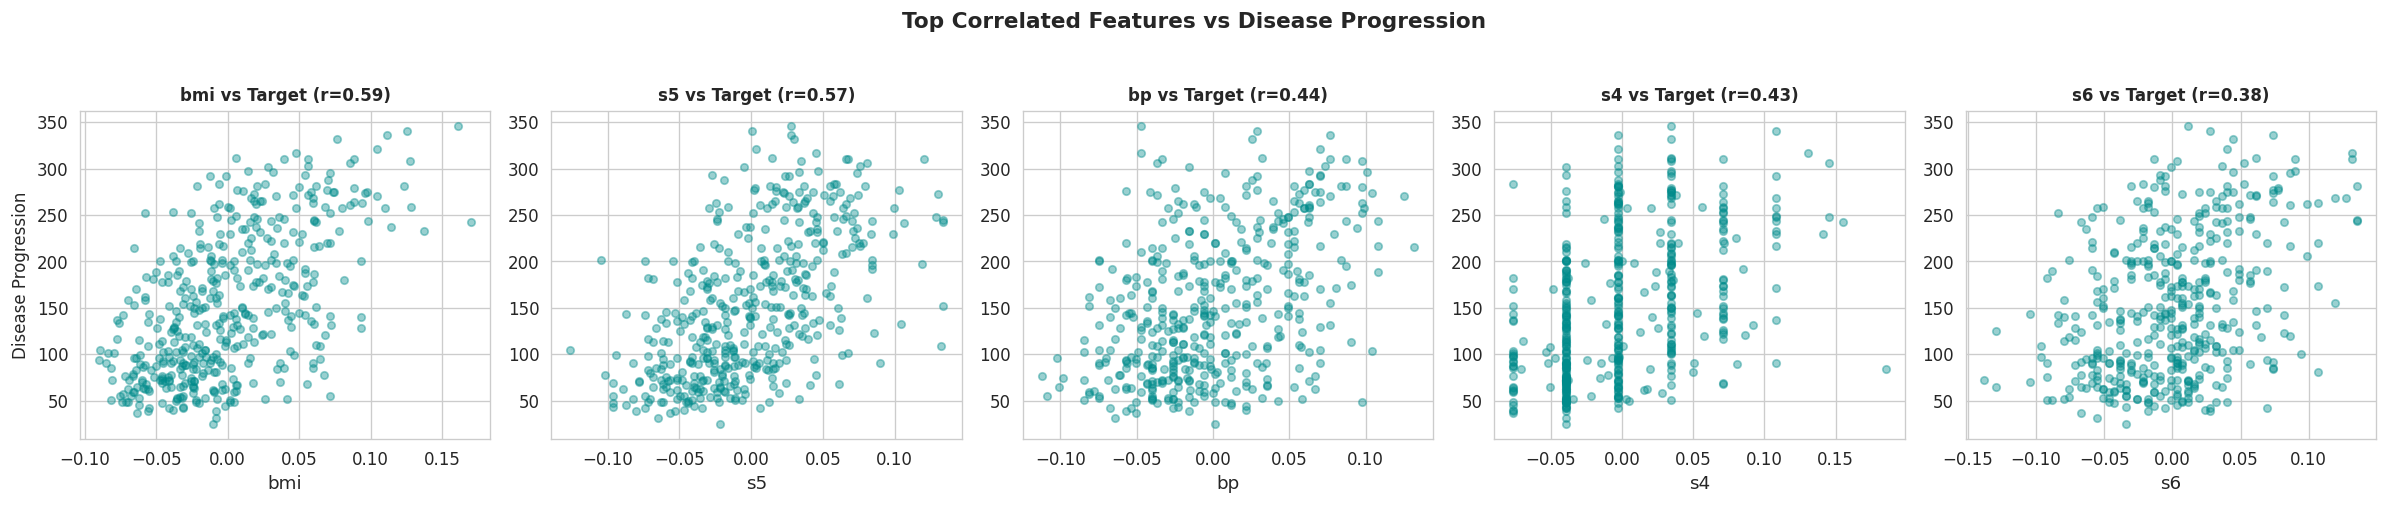


📊 Interpretation:
• bmi and s5 show the clearest linear trends with the target.
• bp (blood pressure) has a moderate positive trend but with more scatter.
• These visuals confirm that a linear model can capture meaningful patterns.


In [10]:
# ── 2.4 Scatter Plots: Top Features vs Target ────────────────────────────────
top_features = ['bmi', 's5', 'bp', 's4', 's6']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df['target'], alpha=0.4, s=20, color='darkcyan')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Disease Progression' if i == 0 else '')
    axes[i].set_title(f'{col} vs Target (r={df[col].corr(df["target"]):.2f})',
                      fontsize=10, fontweight='bold')

fig.suptitle('Top Correlated Features vs Disease Progression', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("• bmi and s5 show the clearest linear trends with the target.")
print("• bp (blood pressure) has a moderate positive trend but with more scatter.")
print("• These visuals confirm that a linear model can capture meaningful patterns.")

---
## 3. Feature Engineering

We analyze feature importance, handle multicollinearity, and decide which features to keep or drop.

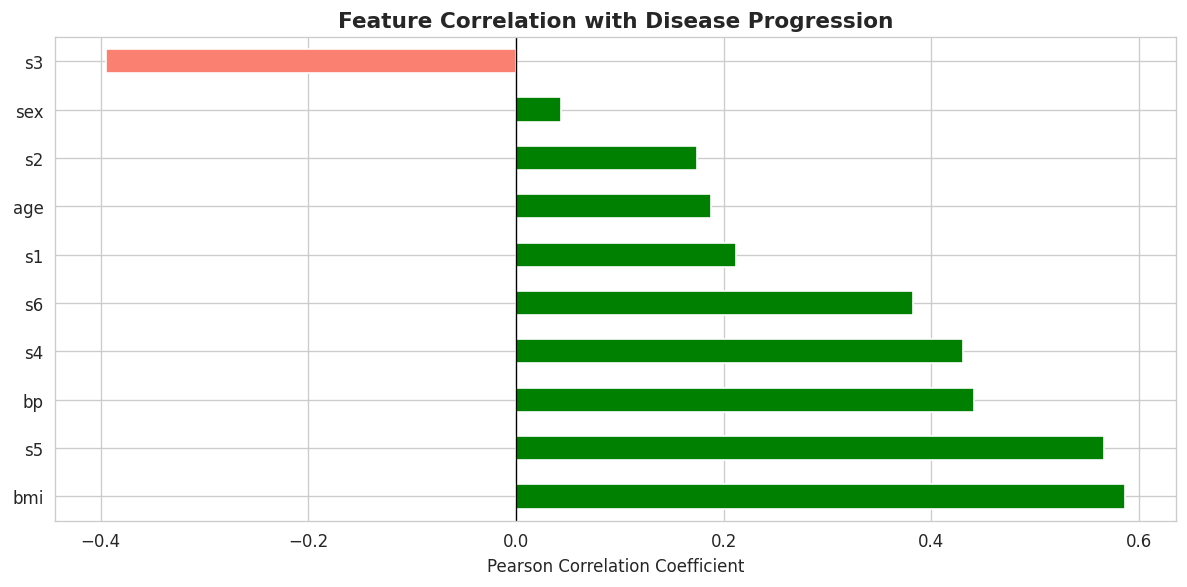


Correlation ranking:
    bmi: +0.586
     s5: +0.566
     bp: +0.441
     s4: +0.430
     s6: +0.382
     s1: +0.212
    age: +0.188
     s2: +0.174
    sex: +0.043
     s3: -0.395


In [11]:
# ── 3.1 Feature Correlations with Target ─────────────────────────────────────
target_corr = df.corr()['target'].drop('target').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if v > 0 else 'salmon' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.set_title('Feature Correlation with Disease Progression', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nCorrelation ranking:")
for feat, corr in target_corr.items():
    print(f"  {feat:>5s}: {corr:+.3f}")

In [12]:
# ── 3.2 Multicollinearity Check ─────────────────────────────────────────────
print("High inter-feature correlations (|r| > 0.7):")
feature_corr = df[features].corr()
for i in range(len(features)):
    for j in range(i+1, len(features)):
        r = feature_corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {features[i]:>5s} ↔ {features[j]:<5s}: r = {r:+.3f}")

print("\n📋 Decision:")
print("• s1 (total cholesterol) and s2 (LDL) are highly correlated (r ≈ 0.90).")
print("• Dropping s1 reduces multicollinearity while retaining s2 which has a")
print("  stronger correlation with the target.")
print("• All other features are retained for model training.")

High inter-feature correlations (|r| > 0.7):
     s1 ↔ s2   : r = +0.897
     s3 ↔ s4   : r = -0.738

📋 Decision:
• s1 (total cholesterol) and s2 (LDL) are highly correlated (r ≈ 0.90).
• Dropping s1 reduces multicollinearity while retaining s2 which has a
  stronger correlation with the target.
• All other features are retained for model training.


In [13]:
# ── 3.3 Apply Feature Engineering ────────────────────────────────────────────
# Drop s1 due to multicollinearity with s2
df_model = df.drop(columns=['s1'])

print(f"Features after engineering: {list(df_model.columns[:-1])}")
print(f"Shape: {df_model.shape}")
print(f"Dropped: s1 (redundant with s2 due to high multicollinearity)")

# Confirm all data is numeric
print(f"\nAll columns numeric: {df_model.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all()}")

Features after engineering: ['age', 'sex', 'bmi', 'bp', 's2', 's3', 's4', 's5', 's6']
Shape: (442, 10)
Dropped: s1 (redundant with s2 due to high multicollinearity)

All columns numeric: True


---
## 4. Data Preparation: Train-Test Split & Standardization

In [14]:
# ── 4.1 Separate features and target ─────────────────────────────────────────
X = df_model.drop(columns=['target'])
y = df_model['target']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")

# ── 4.2 Train-Test Split (80/20) ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Features (X): (442, 9)
Target  (y): (442,)

Training set: 353 samples
Test set:     89 samples


In [15]:
# ── 4.3 Standardize the Data ─────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Standardized training data (first 3 rows):")
print(X_train_scaled.head(3).round(3))
print(f"\nMean of scaled features (should be ~0):  {X_train_scaled.mean().mean():.6f}")
print(f"Std of scaled features  (should be ~1):  {X_train_scaled.std().mean():.6f}")
print("\n✅ Data standardized successfully.")

Standardized training data (first 3 rows):
       age    sex    bmi     bp     s2     s3     s4     s5     s6
17   1.498  1.061  0.220  1.139  1.056 -0.824  0.711  0.547 -0.061
66  -0.229  1.061 -0.419 -0.711  0.272 -1.530  1.484 -0.020  0.367
137  0.085 -0.942  1.019  1.992 -0.327 -0.119 -0.062  0.331 -0.319

Mean of scaled features (should be ~0):  0.000000
Std of scaled features  (should be ~1):  1.001419

✅ Data standardized successfully.


---
## 5. Model Training

We train three models as required:
1. **Linear Regression** (with gradient descent via SGDRegressor)
2. **Decision Tree Regressor**
3. **Random Forest Regressor**

All models use scikit-learn.

In [16]:
# ── 5.1 Linear Regression with Gradient Descent (SGDRegressor) ───────────────
n_epochs = 200
train_losses = []
test_losses = []

sgd_model = SGDRegressor(
    loss='squared_error',
    learning_rate='constant',
    eta0=0.01,
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=42
)

for epoch in range(n_epochs):
    sgd_model.fit(X_train_scaled, y_train)
    y_train_pred = sgd_model.predict(X_train_scaled)
    y_test_pred = sgd_model.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, y_train_pred))
    test_losses.append(mean_squared_error(y_test, y_test_pred))

print("Linear Regression (SGD) trained for 200 epochs.")
print(f"  Final Train MSE: {train_losses[-1]:.2f}")
print(f"  Final Test  MSE: {test_losses[-1]:.2f}")

Linear Regression (SGD) trained for 200 epochs.
  Final Train MSE: 3073.90
  Final Test  MSE: 2966.58


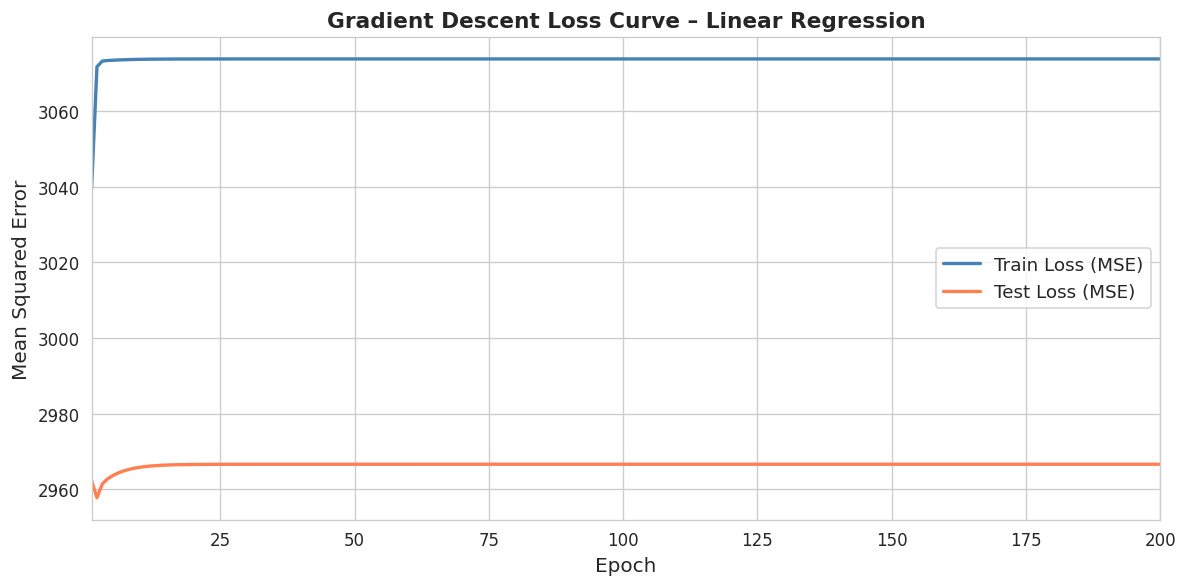


📊 Interpretation:
• Both train and test loss converge rapidly in the first ~50 epochs.
• The small gap between train and test loss indicates good generalization
  (no severe overfitting).


In [17]:
# ── 5.2 Loss Curve: Train vs Test ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, n_epochs + 1), train_losses, label='Train Loss (MSE)', color='steelblue', linewidth=2)
ax.plot(range(1, n_epochs + 1), test_losses, label='Test Loss (MSE)', color='coral', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Gradient Descent Loss Curve – Linear Regression', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(1, n_epochs)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("• Both train and test loss converge rapidly in the first ~50 epochs.")
print("• The small gap between train and test loss indicates good generalization")
print("  (no severe overfitting).")

In [18]:
# ── 5.3 Decision Tree Regressor ──────────────────────────────────────────────
dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)

y_train_pred_dt = dt_model.predict(X_train_scaled)
y_test_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree Regressor (max_depth=5):")
print(f"  Train MSE: {mean_squared_error(y_train, y_train_pred_dt):.2f}")
print(f"  Test  MSE: {mean_squared_error(y_test, y_test_pred_dt):.2f}")

Decision Tree Regressor (max_depth=5):
  Train MSE: 2070.00
  Test  MSE: 3869.85


In [19]:
# ── 5.4 Random Forest Regressor ──────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train_scaled, y_train)

y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Regressor (100 trees, max_depth=5):")
print(f"  Train MSE: {mean_squared_error(y_train, y_train_pred_rf):.2f}")
print(f"  Test  MSE: {mean_squared_error(y_test, y_test_pred_rf):.2f}")

Random Forest Regressor (100 trees, max_depth=5):
  Train MSE: 1603.84
  Test  MSE: 2835.96


---
## 6. Model Comparison & Evaluation

In [20]:
# ── 6.1 Compare All Models ───────────────────────────────────────────────────
models = {
    'Linear Regression (SGD)': (sgd_model, X_test_scaled, y_test),
    'Decision Tree': (dt_model, X_test_scaled, y_test),
    'Random Forest': (rf_model, X_test_scaled, y_test)
}

results = []
for name, (model, X_eval, y_eval) in models.items():
    y_pred = model.predict(X_eval)
    mse = mean_squared_error(y_eval, y_pred)
    mae = mean_absolute_error(y_eval, y_pred)
    r2 = r2_score(y_eval, y_pred)
    results.append({'Model': name, 'MSE': round(mse, 2), 'MAE': round(mae, 2), 'R²': round(r2, 4)})

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("           MODEL COMPARISON (Test Set)")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)

# Identify the best model by lowest MSE
best_idx = results_df['MSE'].idxmin()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n🏆 Best Model: {best_model_name} (lowest test MSE)")


           MODEL COMPARISON (Test Set)
                  Model     MSE   MAE     R²
Linear Regression (SGD) 2966.58 43.45 0.4401
          Decision Tree 3869.85 48.25 0.2696
          Random Forest 2835.96 43.55 0.4647

🏆 Best Model: Random Forest (lowest test MSE)


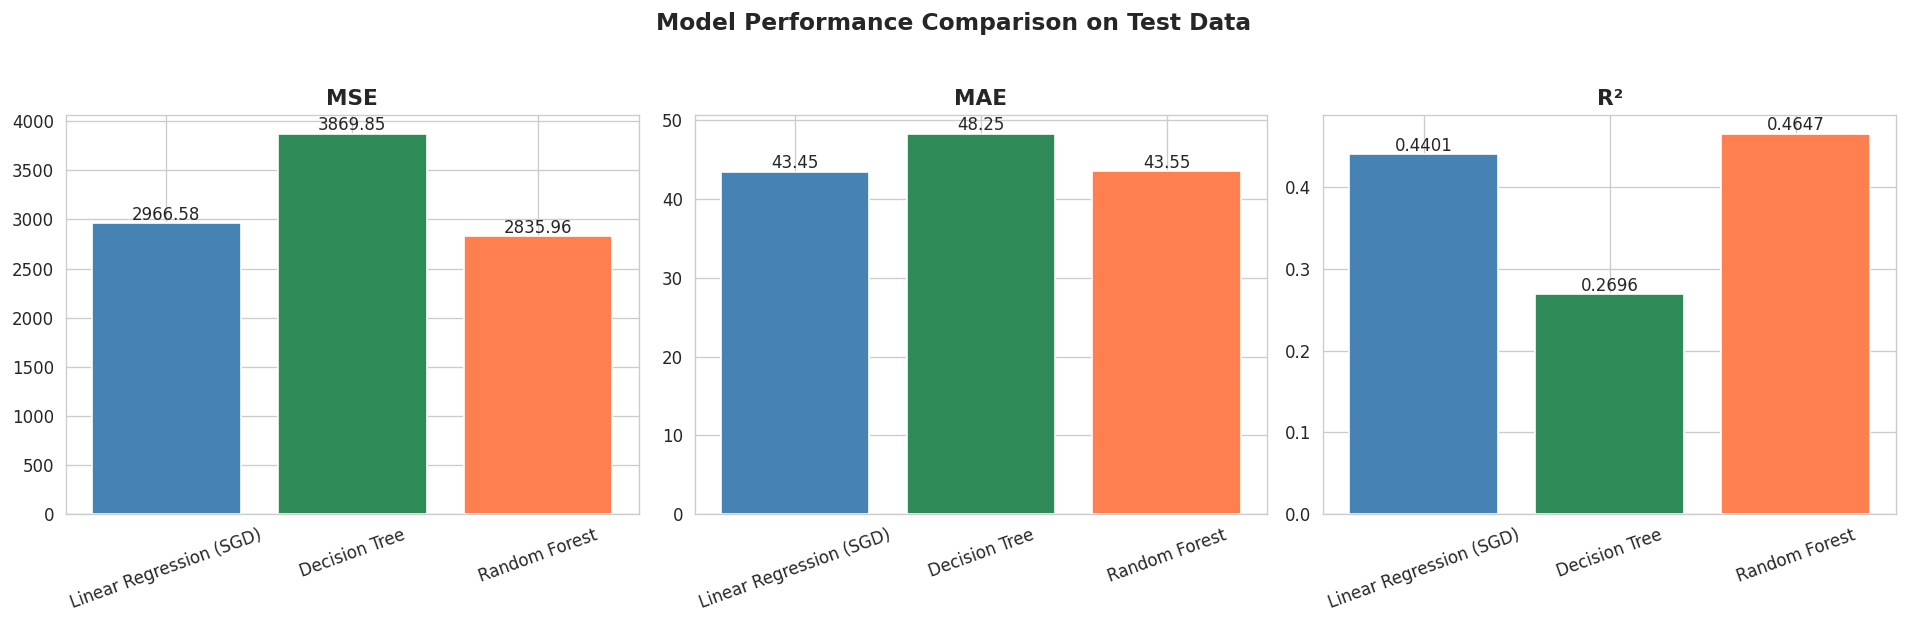

In [21]:
# ── 6.2 Visual Comparison – Bar Chart ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'seagreen', 'coral']

for i, metric in enumerate(['MSE', 'MAE', 'R²']):
    axes[i].bar(results_df['Model'], results_df[metric], color=colors, edgecolor='white')
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)
    for j, val in enumerate(results_df[metric]):
        axes[i].text(j, val + (val * 0.01), str(val), ha='center', fontsize=10)

fig.suptitle('Model Performance Comparison on Test Data', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 7. Scatter Plot – Before and After (Linear Regression Fit)

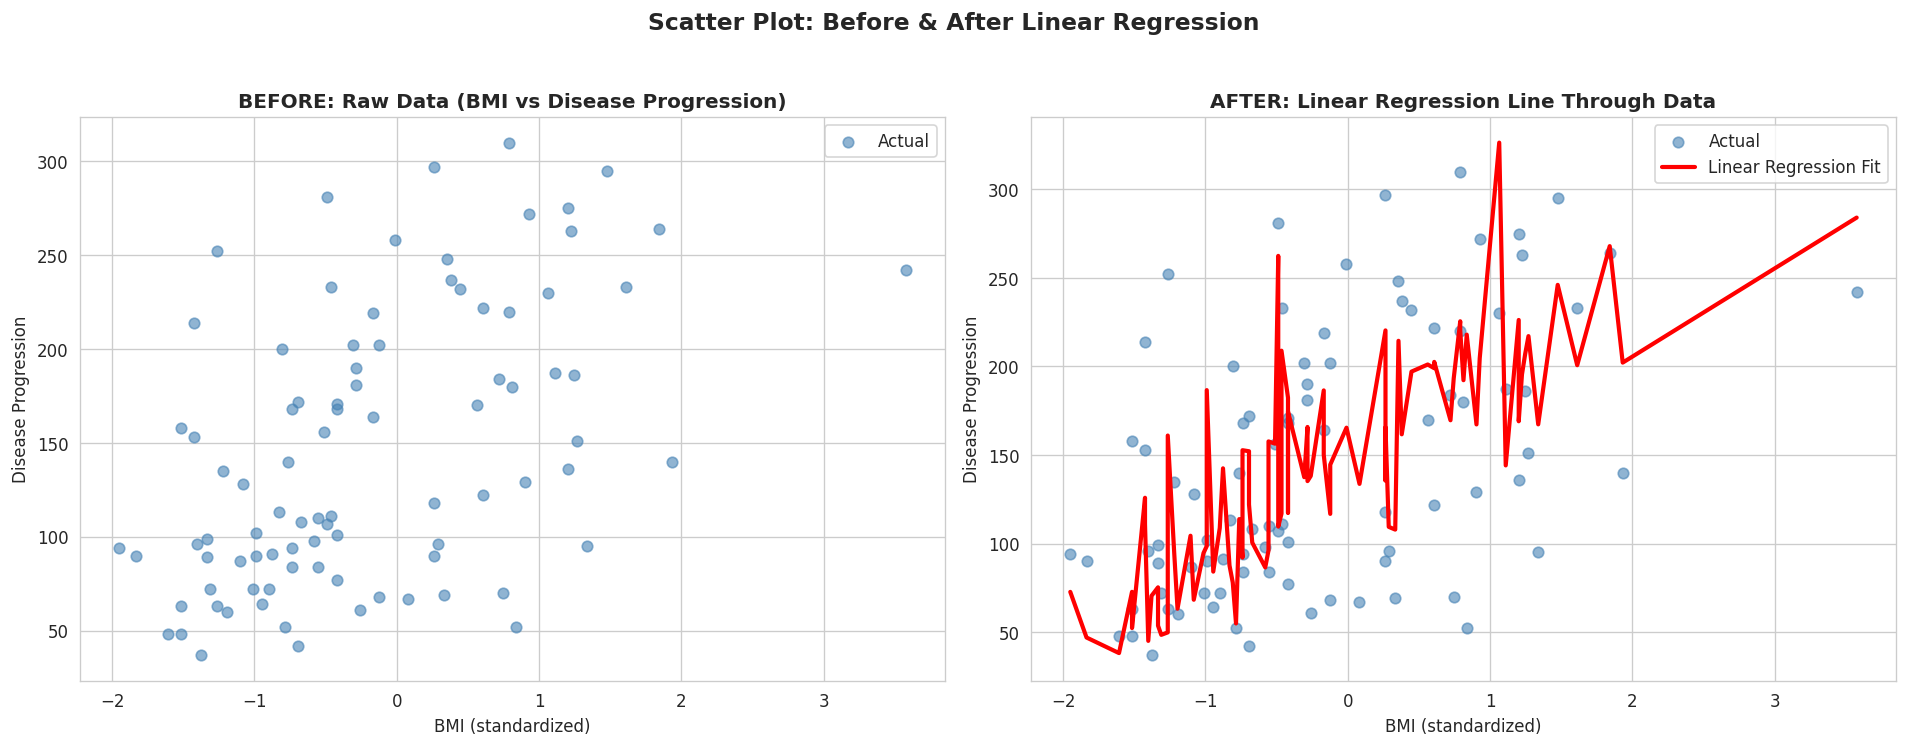


📊 Interpretation:
• The left plot shows the raw relationship – there's a visible positive trend
  but significant scatter (noise).
• The right plot overlays the trained regression line, showing how the model
  captures the general trend of higher BMI → higher disease progression.
• Note: This is a multivariate model projected onto 1 feature; the line reflects
  all 9 features, not just BMI.


In [22]:
# ── 7.1 Scatter: Actual vs Predicted (Before & After) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE: Raw scatter with no regression line
axes[0].scatter(X_test_scaled['bmi'], y_test, alpha=0.6, color='steelblue', s=40, label='Actual')
axes[0].set_title('BEFORE: Raw Data (BMI vs Disease Progression)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('BMI (standardized)')
axes[0].set_ylabel('Disease Progression')
axes[0].legend()

# AFTER: Scatter with linear regression line
y_pred_sgd = sgd_model.predict(X_test_scaled)
axes[1].scatter(X_test_scaled['bmi'], y_test, alpha=0.6, color='steelblue', s=40, label='Actual')
sort_idx = X_test_scaled['bmi'].argsort()
axes[1].plot(X_test_scaled['bmi'].iloc[sort_idx], y_pred_sgd[sort_idx],
             color='red', linewidth=2.5, label='Linear Regression Fit')
axes[1].set_title('AFTER: Linear Regression Line Through Data', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI (standardized)')
axes[1].set_ylabel('Disease Progression')
axes[1].legend()

fig.suptitle('Scatter Plot: Before & After Linear Regression', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("• The left plot shows the raw relationship – there's a visible positive trend")
print("  but significant scatter (noise).")
print("• The right plot overlays the trained regression line, showing how the model")
print("  captures the general trend of higher BMI → higher disease progression.")
print("• Note: This is a multivariate model projected onto 1 feature; the line reflects")
print("  all 9 features, not just BMI.")

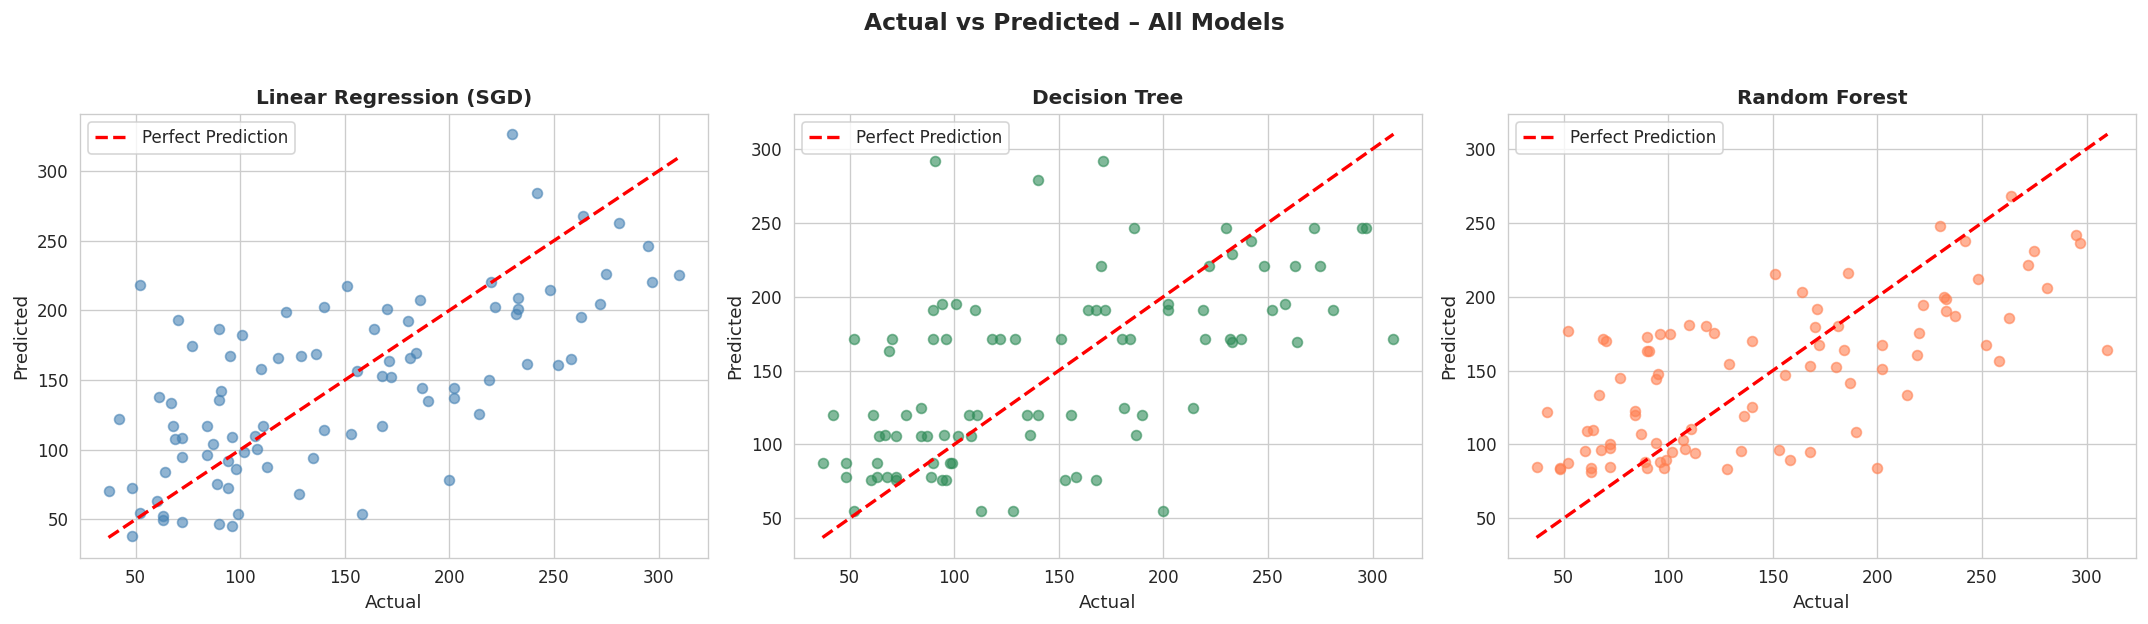

📊 Points closer to the red dashed line = better predictions.


In [23]:
# ── 7.2 Actual vs Predicted scatter for all models ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
predictions = {
    'Linear Regression (SGD)': sgd_model.predict(X_test_scaled),
    'Decision Tree': dt_model.predict(X_test_scaled),
    'Random Forest': rf_model.predict(X_test_scaled)
}

for i, (name, y_pred) in enumerate(predictions.items()):
    axes[i].scatter(y_test, y_pred, alpha=0.6, s=35, color=colors[i])
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                 'r--', linewidth=2, label='Perfect Prediction')
    axes[i].set_xlabel('Actual', fontsize=11)
    axes[i].set_ylabel('Predicted', fontsize=11)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].legend()

fig.suptitle('Actual vs Predicted – All Models', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("📊 Points closer to the red dashed line = better predictions.")

---
## 8. Save the Best-Performing Model

In [24]:
# ── 8.1 Save the best model and scaler ──────────────────────────────────────
model_objects = {
    'Linear Regression (SGD)': sgd_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

best_model = model_objects[best_model_name]

# Save model
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"✅ Best model saved: best_model.pkl  ({best_model_name})")
print(f"✅ Scaler saved:     scaler.pkl")
print(f"\nThese files will be used by the prediction script (Task 2).")

✅ Best model saved: best_model.pkl  (Random Forest)
✅ Scaler saved:     scaler.pkl

These files will be used by the prediction script (Task 2).


---
## 9. Prediction Script

A standalone script that loads the best model and makes a prediction on a single data point.

In [25]:
# ── 9.1 Prediction on a Single Test Sample ──────────────────────────────────
sample = X_test.iloc[[0]]
actual_value = y_test.iloc[0]

# Load model and scaler (simulating a fresh script)
loaded_model = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Scale the sample and predict
sample_scaled = loaded_scaler.transform(sample)
predicted_value = loaded_model.predict(sample_scaled)[0]

print("="*50)
print("  PREDICTION – Single Patient")
print("="*50)
print(f"\nInput features:")
for col, val in zip(sample.columns, sample.values[0]):
    print(f"  {col:>5s}: {val:.4f}")
print(f"\n  Actual disease progression:    {actual_value:.1f}")
print(f"  Predicted disease progression: {predicted_value:.1f}")
print(f"  Absolute error:                {abs(actual_value - predicted_value):.1f}")
print("="*50)

  PREDICTION – Single Patient

Input features:
    age: 0.0453
    sex: -0.0446
    bmi: -0.0062
     bp: -0.0160
     s2: 0.1252
     s3: 0.0192
     s4: 0.0343
     s5: 0.0324
     s6: -0.0052

  Actual disease progression:    219.0
  Predicted disease progression: 160.3
  Absolute error:                58.7


In [26]:
# ── 9.2 Write standalone predict.py script ───────────────────────────────────
predict_script = '''
"""
predict.py – Diabetes Progression Prediction Script
Loads the best-trained model and makes a prediction on new patient data.
Usage: python predict.py
"""

import numpy as np
import joblib

# Load saved model and scaler
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")

# Feature order: age, sex, bmi, bp, s2, s3, s4, s5, s6
# (s1 was dropped during feature engineering)

# Example: single patient data (raw, pre-standardization)
sample_patient = np.array([[
    0.0453,   # age
   -0.0447,   # sex
   -0.0058,   # bmi
   -0.0159,   # bp
   -0.0037,   # s2
    0.0081,   # s3
   -0.0396,   # s4
   -0.0031,   # s5
    0.0112,   # s6
]])

# Scale and predict
sample_scaled = scaler.transform(sample_patient)
prediction = model.predict(sample_scaled)[0]

print(f"Predicted diabetes progression score: {prediction:.2f}")
'''

with open('predict.py', 'w') as f:
    f.write(predict_script)

print("✅ predict.py written successfully.")
print("   Run with: python predict.py")

✅ predict.py written successfully.
   Run with: python predict.py


---
## Summary

| Step | Status |
|------|--------|
| Healthcare dataset (non-generic, non-house-price) | ✅ Diabetes progression |
| Visualizations with interpretation | ✅ Heatmap, distributions, scatter plots |
| Feature engineering (drop/select, interpret) | ✅ Dropped s1 (multicollinearity) |
| Numeric conversion check | ✅ All features already numeric |
| Standardization | ✅ StandardScaler applied |
| Linear Regression with gradient descent | ✅ SGDRegressor (200 epochs) |
| Decision Tree model | ✅ DecisionTreeRegressor |
| Random Forest model | ✅ RandomForestRegressor |
| Loss curve (train & test) | ✅ MSE over epochs plotted |
| Scatter plot before & after | ✅ Raw data vs regression line |
| Save best model | ✅ best_model.pkl + scaler.pkl |
| Prediction script | ✅ predict.py created |

**Mission:** Applying AI Tools in Healthcare  
**Outcome:** A complete regression pipeline for predicting diabetes disease progression from patient clinical data.